In [1]:
import pandas as pd

In [2]:
file_path = "../data/Grand_Theft_Auto_V.jsonlines"

df = pd.read_json(file_path, lines=True)

In [ ]:
df.head()

In [4]:
df.shape

(13349, 27)

In [5]:
df.columns.tolist()

['num_found_funny',
 'review_url',
 'num_guides',
 'total_game_hours',
 'num_workshop_items',
 'num_found_unhelpful',
 'steam_id_number',
 'username',
 'num_found_helpful',
 'total_game_hours_last_two_weeks',
 'date_posted',
 'num_comments',
 'profile_url',
 'rating',
 'num_reviews',
 'orig_url',
 'num_groups',
 'num_games_owned',
 'friend_player_level',
 'date_updated',
 'found_helpful_percentage',
 'num_screenshots',
 'review',
 'achievement_progress',
 'num_voted_helpfulness',
 'num_badges',
 'num_friends']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13349 entries, 0 to 13348
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   num_found_funny                  13349 non-null  int64  
 1   review_url                       13349 non-null  str    
 2   num_guides                       13349 non-null  int64  
 3   total_game_hours                 13349 non-null  float64
 4   num_workshop_items               13349 non-null  int64  
 5   num_found_unhelpful              13349 non-null  int64  
 6   steam_id_number                  13349 non-null  str    
 7   username                         13349 non-null  str    
 8   num_found_helpful                13349 non-null  int64  
 9   total_game_hours_last_two_weeks  13349 non-null  float64
 10  date_posted                      13349 non-null  str    
 11  num_comments                     13349 non-null  int64  
 12  profile_url                  

In [7]:
df["rating"].value_counts()

rating
Recommended        8613
Not Recommended    4736
Name: count, dtype: int64

In [ ]:
df[["rating", "review"]].head(10)

In [ ]:
pd.set_option("display.max_colwidth", None)

df[["rating", "review"]].head(5)

In [10]:
df["review"].duplicated().sum()

np.int64(2159)

In [ ]:
duplicate_reviews = df[df["review"].duplicated(keep=False)]

duplicate_reviews[["rating", "review"]].sort_values("review").head(10)

In [ ]:
duplicate_reviews[
    ["username", "date_posted", "rating", "review_url", "review"]
].sort_values("review").head(10)

In [13]:
df.duplicated(subset=["review"]).sum()

np.int64(2159)

In [14]:
df.duplicated(
    subset=["review_url", "username", "date_posted", "rating", "review"]
).sum()

np.int64(2069)

In [15]:
df_clean = df.drop_duplicates(subset=["review"]).copy()

In [16]:
df_clean.shape

(11190, 27)

In [17]:
(df_clean["review"].str.strip() == "").sum()

np.int64(0)

In [18]:
df_clean["review"].str.split().str.len().describe()

count    11190.000000
mean        61.725737
std        113.243310
min          1.000000
25%         10.000000
50%         24.000000
75%         63.000000
max       1498.000000
Name: review, dtype: float64

In [19]:
df_clean["word_count"] = df_clean["review"].str.split().str.len()

In [ ]:
df_clean[
    ["rating", "word_count", "review"]
].sort_values("word_count").head(15)

In [21]:
short_review_counts = {
    "1 Wort": (df_clean["word_count"] == 1).sum(),
    "höchstens 3 Wörter": (df_clean["word_count"] <= 3).sum(),
    "höchstens 5 Wörter": (df_clean["word_count"] <= 5).sum(),
    "höchstens 10 Wörter": (df_clean["word_count"] <= 10).sum()
}

short_review_counts

{'1 Wort': np.int64(46),
 'höchstens 3 Wörter': np.int64(418),
 'höchstens 5 Wörter': np.int64(1072),
 'höchstens 10 Wörter': np.int64(2818)}

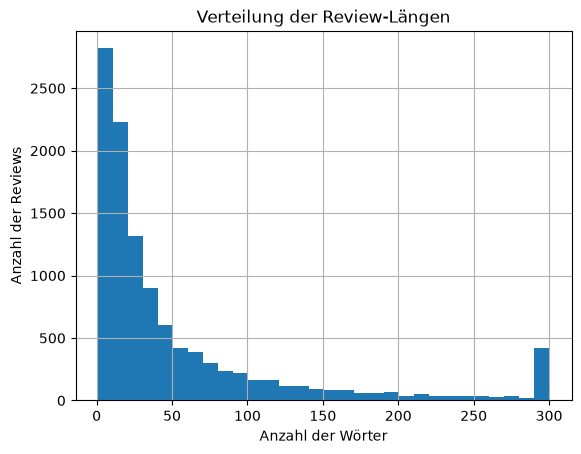

In [22]:
import matplotlib.pyplot as plt

df_clean["word_count"].clip(upper=300).hist(bins=30)

plt.title("Verteilung der Review-Längen")
plt.xlabel("Anzahl der Wörter")
plt.ylabel("Anzahl der Reviews")
plt.show()

In [23]:
(df_clean["word_count"] > 300).sum()

np.int64(400)

## Zwischenfazit der Datenexploration

Der Rohdatensatz enthält 13.349 Einträge und 27 Merkmale. Die für die Analyse zentrale Spalte `review` enthält keine fehlenden oder leeren Werte. Nach dem Entfernen von 2.159 identischen Review-Texten verbleiben 11.190 eindeutige Reviews.

Die Bewertungen sind ungleich verteilt: 8.613 Einträge sind als „Recommended“ und 4.736 als „Not Recommended“ gekennzeichnet. Die Review-Längen sind stark rechtsschief verteilt. Der Median liegt bei 24 Wörtern, während einzelne Reviews bis zu 1.498 Wörter enthalten. 400 Reviews sind länger als 300 Wörter. Sehr kurze Reviews werden zunächst nicht entfernt, da die endgültige Nutzbarkeit erst nach der Textvorverarbeitung beurteilt werden kann.